<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Exploratory Data Analysis on Online Course Enrollment Data**


## **Introduction**

In this lab, we will explore the course rating dataset before building any recommendation models.
This step is called **Exploratory Data Analysis** (EDA).


Exploratory Data Analysis means carefully examining the data to understand its structure, find patterns, and detect any potential problems.
We use summary statistics and visualizations to see how the data looks before applying machine learning models. 

In this lab, we will explore two datasets related to online courses, including:
- Course information such as titles and genres
- User enrollment records and their ratings

By analyzing these datasets, we can better understand how users interact with courses.
This will help us prepare the data for building recommendation models in later labs.

## **Objectives**


* Identify keywords in course titles using a WordCloud
* Calculate the summary statistics and visualizations of the online course content dataset
* Determine popular course genres
* Calculate the summary statistics and create visualizations of the online course enrollment dataset
* Identify courses with the greatest number of enrolled students


----


### **Prepare and setup the lab environment**


At the beginning, we need to install two required Python packages:


In [32]:
#!pip install seaborn
#!pip install wordcloud
#!pip install pandas
#!pip install matplotlib

and import necessary class/methods in the packages


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

%matplotlib inline

In [34]:
# also set a random state
rs = 123

### **Load and explore the dataset**


First, let's load the datasets as `Pandas` dataframes and start some basic exploratory data analysis tasks on them.


In [35]:
# Point to the datasets stored on the cloud
course_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv"
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"

In [36]:
course_df = pd.read_csv(course_genre_url)
ratings_df = pd.read_csv(ratings_url)

We will start by exploring the course genre dataset. Let's first check its columns/features name:


In [37]:
course_df.columns

Index(['COURSE_ID', 'TITLE', 'Database', 'Python', 'CloudComputing',
       'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision',
       'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev',
       'Blockchain'],
      dtype='object')

We can see from the above cell output that the columns represent some metadata about a course such as its id, title, and genres. We can see that the course genres are some popular topics related to machine learning, databases, app developments, etc.


We can also check how many unique courses we have in this dataset:


In [38]:
course_df['COURSE_ID'].nunique()

307

Then we can take a quick look at its header rows


In [39]:
course_df.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [40]:
course_df.dtypes

COURSE_ID          object
TITLE              object
Database            int64
Python              int64
CloudComputing      int64
DataAnalysis        int64
Containers          int64
MachineLearning     int64
ComputerVision      int64
DataScience         int64
BigData             int64
Chatbot             int64
R                   int64
BackendDev          int64
FrontendDev         int64
Blockchain          int64
dtype: object

As we can see, the `COURSE_ID` and `TITLE` are `str` datatypes and all the course genres are binary/int datatypes. 

**Any genre column with value 1 means the course is associated with the course genre while 0 means the course is not.**


For example, the following course `accelerating deep learning with gpu` is associated with genres `Python`, `MachineLearning`, and `DataScience`


In [41]:
course_df.iloc[1, ]

COURSE_ID                                     ML0122EN
TITLE              accelerating deep learning with gpu
Database                                             0
Python                                               1
CloudComputing                                       0
DataAnalysis                                         0
Containers                                           0
MachineLearning                                      1
ComputerVision                                       0
DataScience                                          1
BigData                                              0
Chatbot                                              0
R                                                    0
BackendDev                                           0
FrontendDev                                          0
Blockchain                                           0
Name: 1, dtype: object

Next, let's focus on the course title column by trying to determine keywords in the titles. Those keywords in the titles may give us a more intuitive summary of what kind of courses we have in the dataset.


### **Plot a Word Cloud from Course Titles**


First, let's join all the title values into one string, then we can conveniently get a wordcloud from the big string:


In [42]:
titles = " ".join(title for title in course_df['TITLE'].astype(str))

In [43]:
titles

'robots are coming  build iot apps with watson  swift  and node red accelerating deep learning with gpu consuming restful services using the reactive jax rs client analyzing big data in r using apache spark containerizing  packaging  and running a spring boot application cloud native security conference  data security data science bootcamp with r for university proffesors learn how to use docker containers for iterative development scorm test course create your first mongodb database testing microservices with the arquillian managed container cloud pak for integration essentials watson analytics for social media data science bootcamp with python for university professors  advance create a cryptocurrency trading algorithm in python data   ai essentials securing java microservices with eclipse microprofile json web token  microprofile jwt  enabling distributed tracing in microservices with zipkin sql access for hadoop ybrid cloud conference  ai pipelines lab dataops methodology data   ai

We also want to filter common stop words and some less meaningful words:


In [44]:
# English Stopwords
# In NLP libraries (like WordCloud), STOPWORDS is a built-in list of common words that are usually removed from text because they are not informative.
stopwords = set(STOPWORDS)

# adds additional words to the stopwords set
stopwords.update(["getting started", 
                  "using", 
                  "enabling", 
                  "template", 
                  "university", 
                  "end", 
                  "introduction", 
                  "basic"])

Then, we create a ```WordCloud``` object and generate ```wordcloud``` from the titles.


In [45]:
wordcloud = WordCloud(stopwords=stopwords, 
                      background_color="white", 
                      width=800, 
                      height=400)

In [46]:
wordcloud.generate(titles)

In [47]:
word_freq = wordcloud.words_
freq_df = pd.DataFrame(list(word_freq.items()), columns=['Word', 'Frequency'])
freq_df = freq_df.sort_values('Frequency', ascending=False).reset_index(drop=True)


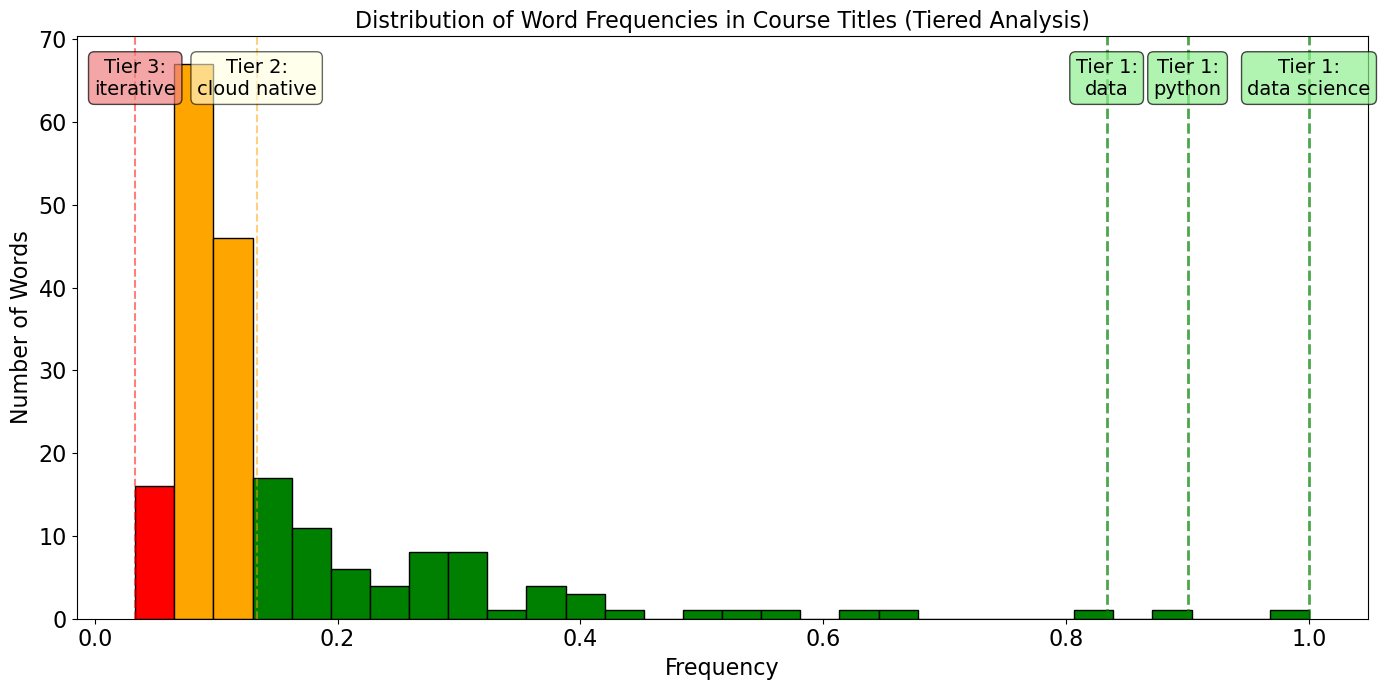

In [48]:
# Categorize words into three tiers
tier_1 = freq_df.head(len(freq_df)//3)
tier_3 = freq_df.tail(len(freq_df)//3)
tier_2 = freq_df.iloc[len(freq_df)//3:-len(freq_df)//3]

plt.figure(figsize=(14, 7))

# Define tier thresholds
tier_1_threshold = tier_1['Frequency'].min()
tier_3_threshold = tier_3['Frequency'].max()

# Plot histogram with tier colors
n, bins, patches = plt.hist(freq_df['Frequency'], bins=30, edgecolor='black')

# Assign colors to each bar based on bin values
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center >= tier_1_threshold:
        patch.set_facecolor('green')
    elif bin_center <= tier_3_threshold:
        patch.set_facecolor('red')
    else:
        patch.set_facecolor('orange')

plt.tick_params(labelsize=16)
plt.xlabel('Frequency', fontsize=16)
plt.ylabel('Number of Words', fontsize=16)
plt.title('Distribution of Word Frequencies in Course Titles (Tiered Analysis)', fontsize=16)

# Add annotations for Tier 1
sample_tier_1 = tier_1.iloc[0:3]
for idx, row in sample_tier_1.iterrows():
    plt.axvline(row['Frequency'], color='green', linestyle='--', linewidth=2, alpha=0.7)
    plt.text(row['Frequency'], plt.ylim()[1] * 0.9, f"Tier 1:\n{row['Word']}", 
             fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Add annotations for Tier 2
sample_tier_2 = tier_2.head(1)
for idx, row in sample_tier_2.iterrows():
    plt.axvline(row['Frequency'], color='orange', linestyle='--', linewidth=1.5, alpha=0.5)
    plt.text(row['Frequency'], plt.ylim()[1] * 0.9, f"Tier 2:\n{row['Word']}", 
             fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.6))

# Add annotations for Tier 3
sample_tier_3 = tier_3.tail(1)
for idx, row in sample_tier_3.iterrows():
    plt.axvline(row['Frequency'], color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    plt.text(row['Frequency'], plt.ylim()[1] * 0.9, f"Tier 3:\n{row['Word']}", 
             fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.show()

We can use `plt.imshow()` method to visualize the generated wordcloud:


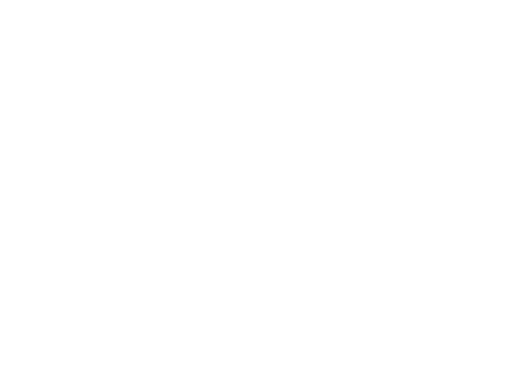

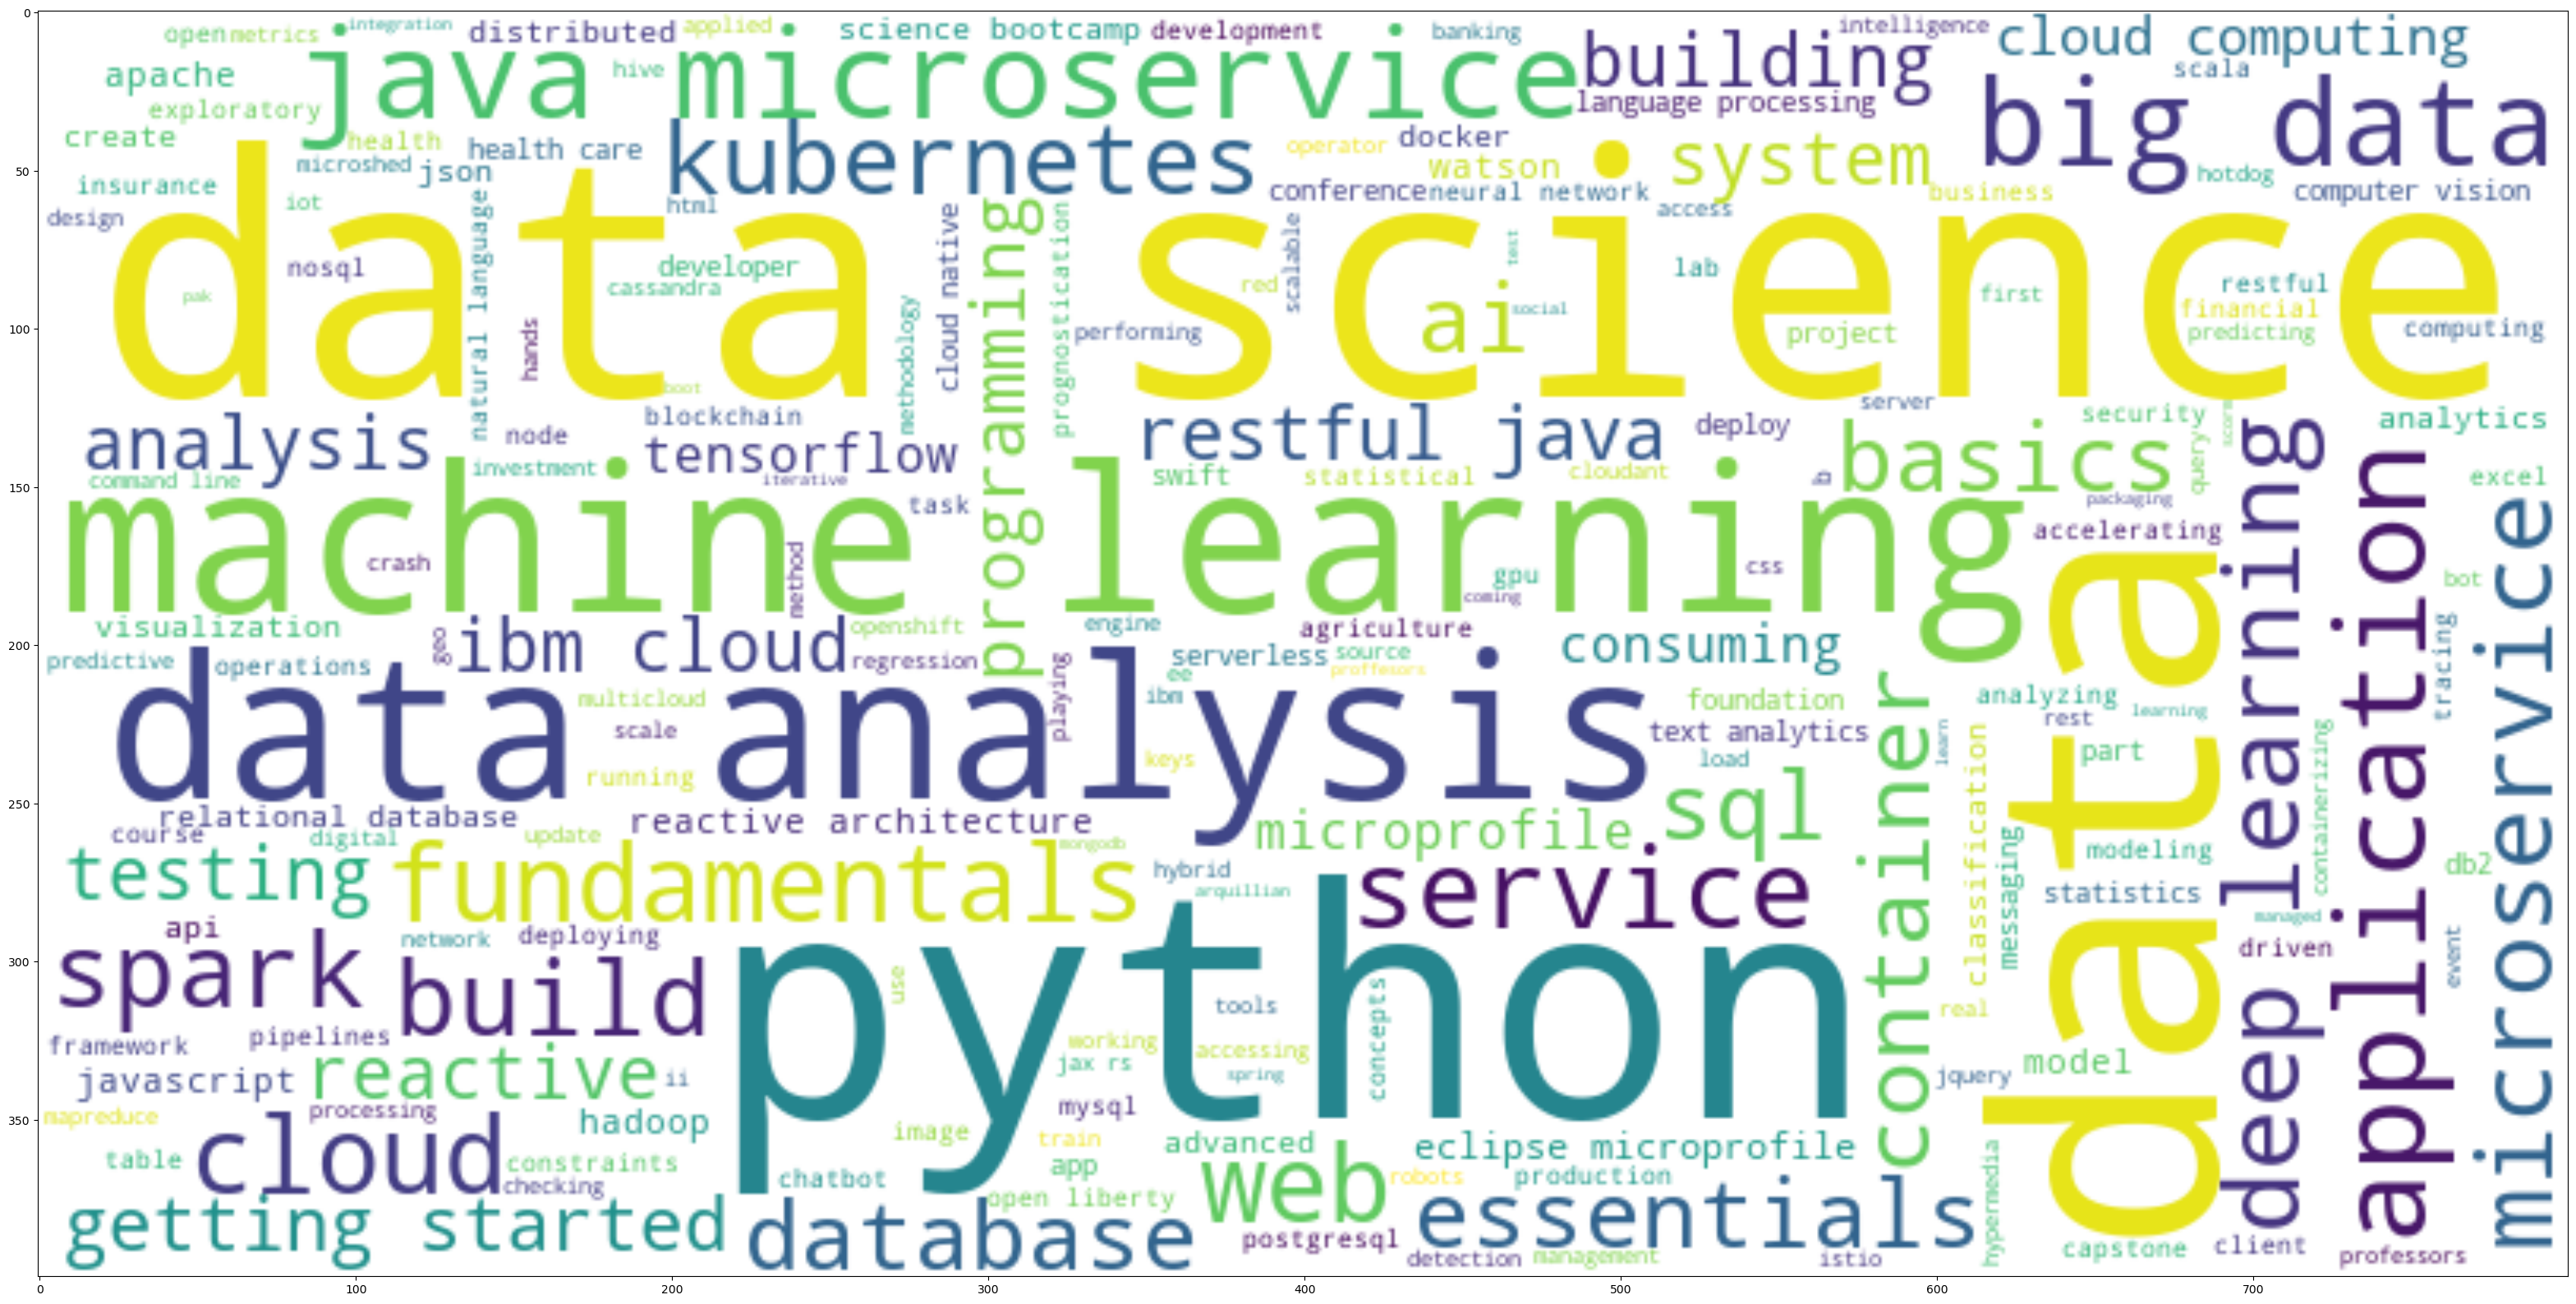

In [49]:
# Disable axis display
plt.axis("off")
# Create a new figure with a specified size
plt.figure(figsize=(40,20))
# Adjust the layout to ensure tight spacing
plt.tight_layout(pad=0)
# Display the word cloud image with bilinear interpolation
plt.imshow(wordcloud.to_image(), 
           interpolation='bilinear')
# Show the plot
plt.show()

As we can see from the ```wordcloud```,  there are many popular IT related keywords such as python, data science, machine learning, big data, ai, tensorflow, container, cloud, etc. By looking at these keywords, we should have a general understanding that the courses in the dataset are focused on demanding IT skills.


Next, we perform some more detailed analysis on the course dataset.


### **Analyze Course Genres**


First, we can try to find out which courses may be of interest you. For example, what are the all machine learning related courses?


_TODO: Find all courses with genre `MachineLearning` == 1_


In [50]:
ml_courses = course_df[course_df['MachineLearning'] == 1]
ml_courses.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
15,DAI101EN,data ai essentials,0,0,0,0,0,1,0,0,0,0,0,0,0,0
19,HCC105EN,ybrid cloud conference ai pipelines lab,0,0,0,0,0,1,0,0,0,0,0,0,0,0
21,DS0132EN,data ai jumpstart your journey,0,0,0,0,0,1,0,0,0,0,0,0,0,0
24,BENTEST4,ai for everyone master the basics,0,0,0,0,0,1,0,0,0,0,0,0,0,0


<details>
    <summary>Click here for Hints</summary>
    
You can find the indexes of all courses with genre `MachineLearning` == 1 by using: 
    
```python
course_df['MachineLearning'] == 1
```
Then you can find the courses by using the indexes:
    
```python
ml_courses = course_df[indexes]
```
</details>


Similarly, we can try to find out what are the scalable machine learning courses?


_TODO: Find all courses with genres `MachineLearning` == 1 and `BigData` == 1_


In [51]:
ml_bd_courses = ml_courses[ml_courses['BigData']==1]
ml_bd_courses

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
46,GPXX0BUBEN,insurance risk assessment with montecarlo meth...,0,0,0,0,0,1,0,0,1,0,0,0,0,0
59,TA0106EN,text analytics at scale,0,0,0,0,0,1,0,1,1,0,0,0,0,0
184,BD0221EN,spark mllib,0,0,0,0,0,1,0,0,1,0,0,0,0,0
282,excourse69,machine learning with big data,0,0,0,0,0,1,0,0,1,0,0,0,0,0


<details>
    <summary>Click here for Hints</summary>

You can find them by using previously found dataset of all courses with genre `MachineLearning` == 1_ and finding all courses with `BigData` == 1_ . Indexes can be found by using:
    
    
```python
mouse_df['BigData'] == 1
```


In [52]:
genres = course_df.columns[2:]
genres

Index(['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers',
       'MachineLearning', 'ComputerVision', 'DataScience', 'BigData',
       'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain'],
      dtype='object')

Given all the course genres, now let's calculate the course count for each genre. e.g., there are 69 courses that belong to the `MachineLearning` genre and 23 courses that belong to the `Python` genre. We also want to sort the genre count list to find the most popular course genres.


_TODO: Use the Pandas dataframe sum() and sort_values() methods to genreate a sorted course count per genre. You may also implement the task with different solutions_


In [53]:
course_df[genres].sum(axis=0)

Database           60
Python             28
CloudComputing     37
DataAnalysis       56
Containers         17
MachineLearning    69
ComputerVision     10
DataScience        38
BigData            36
Chatbot             4
R                  17
BackendDev         78
FrontendDev        19
Blockchain          4
dtype: int64

In [54]:
genre_sums = pd.DataFrame(course_df[genres].sum(axis=0), columns = ['Count']).sort_values(by = "Count", ascending=False)
genre_sums

,Count
BackendDev,78
MachineLearning,69
Database,60
DataAnalysis,56
DataScience,38
CloudComputing,37
BigData,36
Python,28
FrontendDev,19
Containers,17


<details>
    <summary>Click here for Hints</summary>

You can use `course_df[genres].sum(axis=0)` to sum the values, then use `pd.DataFrame(genre_sums, columns = ['Count'])` to convert it into a data frame, apply `.sort_values(by = "Count", ascending=False)` on the resulted course count data set to sort it.


We can also visualize course genre counts using a bar chart:


_TODO: Use seaborn barplot or other plot methods to plot course genre counts using a barchart. The x-axis is the course genre and the y-axis is the course count per genre._


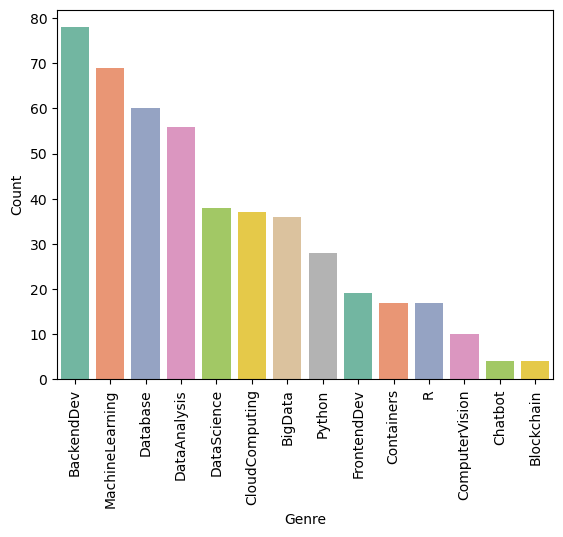

In [55]:
sns.barplot(x=genre_sums.index, 
            y="Count", 
            hue=genre_sums.index, 
            data=genre_sums, 
            palette="Set2")
plt.xlabel("Genre") 
plt.xticks(rotation=90)
plt.show()

<details>
    <summary>Click here for Hints</summary>
    
You can use `sns.barplot(x=genre_sums.index, y="Count", data=genre_sums)` to create your plot. you can rotate your labels by using `plot.set_xticklabels(plot.get_xticklabels(),rotation = 90)` method.


Now, we have some solid understanding about all course metadata including the keywords in titles and popular course genres. Next, we will switch gears to exploring course learners related datasets.


###  **Analyze Course Enrollments**


Let's first take a look at the course enrollments dataset.


In [56]:
ratings_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


This dataset contains three colums, `user` representing a unique user id, `item` representing a course id, and `rating` representing the ratings given by the user.


In [57]:
ratings_df['rating'].unique()

array([5, 3, 4])

The **rating** column consists of three potential values: 

- A rating of <code>5</code> signifies that users who have enrolled in the course find it excellent and have given it the highest rating, thus recommending it to other learners. 

- A rating of <code>4</code>, indicates that the enrolled users perceive the course as good and will recommend to the other learners,but suggest minor improvements. 

- A rating of <code>3</code>indicates that enrolled users find the course below expectations and need significant modifications.


Let's see how many ratings we have in the dataset:


In [58]:
ratings_df.shape

(233306, 3)

We have 233306 enrollments. In fact, each user is likely to interact with multiple items so let's find the rating counts for each user:


_TODO: Apply Pandas' groupby() and size() method on the user column to aggregate the rating count for each user, then report the total number of users after aggregation._


In [59]:
ratings_sums = pd.DataFrame(ratings_df.groupby('user').size(), columns = ['Count'])
ratings_sums

,Count
user,
2,61
4,44
5,59
7,1
8,3
...,...
2102054,8
2102356,1
2102680,11


<details>
    <summary>Click here for Hints</summary>
    
You can use `ratings_df.groupby('user')` to group by `user` and then `.size()` method to aggregate the rating count 


After the aggregation, you should get a new dataframe showing the rating count for each user. For example, user 4 rated 44 items and user 2 rated 61 items. Next, let's try to get some summary statistics and visualizations from the user ratings count dataframe.


_TODO: Use describe() to report the statistics summary of the user enrollments._


In [60]:
ratings_sums.describe()

,Count
count,33901.000000
mean,6.881980
std,5.823548
min,1.000000
25%,2.000000
50%,6.000000
75%,9.000000
max,61.000000


We can also get a histogram showing the enrollment distributions, e.g., how many users rated just 1 item or how many rated 10 items, etc.


_TODO: Plot the histogram of user rating counts._


Text(0.5, 0, 'Enrollments per User')

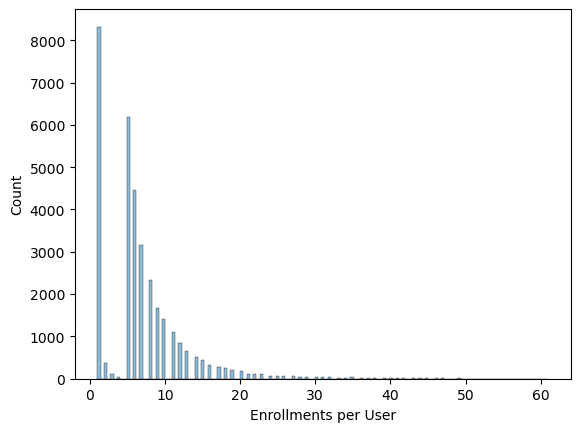

In [61]:
sns.histplot(ratings_sums,legend=False)
plt.xlabel("Enrollments per User") 

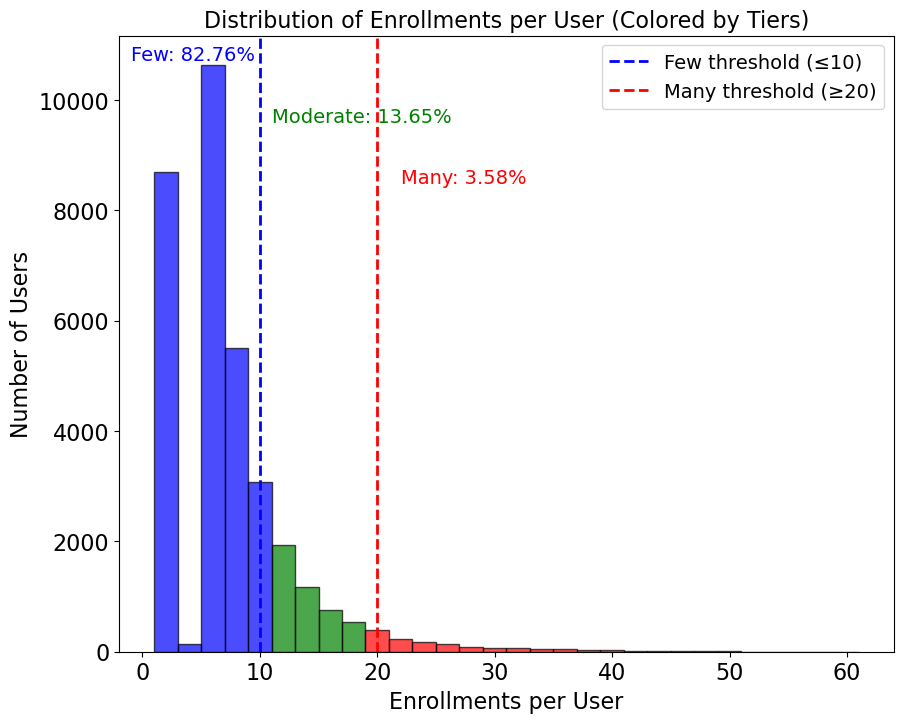

In [62]:
plt.figure(figsize=(10, 8))
n, bins, patches = plt.hist(ratings_sums['Count'], bins=30, edgecolor='black', alpha=0.7)

# Define thresholds for tiers
few_threshold = 10
many_threshold = 20

# Calculate the percentage of users in each enrollment tier.
total_users = len(ratings_sums)
few_pct = (ratings_sums["Count"] <= few_threshold).mean() * 100
many_pct = (ratings_sums["Count"] >= many_threshold).mean() * 100
moderate_pct = (
    (ratings_sums["Count"] > few_threshold)
    & (ratings_sums["Count"] < many_threshold)
).mean() * 100

# Color bars based on bin centers
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center <= few_threshold:
        patch.set_facecolor('blue')  # Few enrollments
    elif bin_center >= many_threshold:
        patch.set_facecolor('red')   # Many enrollments
    else:
        patch.set_facecolor('green') # Moderate enrollments

plt.xlabel("Enrollments per User", fontsize=16)
plt.ylabel("Number of Users", fontsize=16)
plt.tick_params(labelsize=16)
plt.title("Distribution of Enrollments per User (Colored by Tiers)", fontsize=16)

# Add vertical lines for thresholds
plt.axvline(few_threshold, color='blue', linestyle='--', linewidth=2, label=f'Few threshold (≤{few_threshold})')
plt.axvline(many_threshold, color='red', linestyle='--', linewidth=2, label=f'Many threshold (≥{many_threshold})')

# Add text annotations for percentages (assuming percentages are calculated as before)
# (Include the percentage calculation code here if needed, or reference the previous cell)
plt.text(few_threshold - 11, plt.ylim()[1] * 0.96, f'Few: {few_pct:.2f}%', fontsize=14, color='blue')
plt.text(many_threshold + 2, plt.ylim()[1] * 0.76, f'Many: {many_pct:.2f}%', fontsize=14, color='red')
plt.text((many_threshold + 2) / 2, plt.ylim()[1] * 0.86, f'Moderate: {moderate_pct:.2f}%', fontsize=14, color='green')

plt.legend(fontsize=14)
plt.show()

# ...existing code...

<details>
    <summary>Click here for Hints</summary>
    
You can use `.hist()` command on yout data set


### **Find the Top-20 Most Popular Courses**


Now we know how many items each user rated. Let's see the most popular 20 courses, i.e., items with the most rating counts.


_TODO: Use Pandas groupby() and size() methods on the item column to aggregate the rating count for each item, then use the sort_values() method to sort the course enrollment count, and use the slice method to get the top 20 courses. You may also implement this task with different solutions_


In [63]:
top_courses = pd.DataFrame(ratings_df.groupby(['item']).size().rename('Enrolls').reset_index()).sort_values(by='Enrolls', ascending=False)
top20_courses = top_courses.head(20)
top20_courses

,item,Enrolls
101,PY0101EN,14936
54,DS0101EN,14477
4,BD0101EN,13291
5,BD0111EN,10599
42,DA0101EN,8303
55,DS0103EN,7719
82,ML0101ENv3,7644
18,BD0211EN,7551
56,DS0105EN,7199
1,BC0101EN,6719


<details>
    <summary>Click here for Hints</summary>
    
You can use `.groupby(['item']).size().reset_index()` on the `ratings_df` to get the aggregated ratings count then you can apply `.columns=['course', 'Ratings']` to set the proper column names. Then apply `.sort_values(by='Ratings', ascending=False).reset_index(drop=True)`. Don't forger to choose the top 20 courses.


Now you may only see the item IDs which do not indicate what kind of courses they are. To make it more clear, we need to join the course titles in the course metadata dataset (`course_df`) so that we can identify what the most popular courses are immediately:


_TODO: Use Pandas merge() method to join the course_df (contains the course title column)._


In [64]:
top_courses.shape, course_df.shape

((126, 2), (307, 16))

In [65]:
top20_courses.merge(course_df[['COURSE_ID', 'TITLE']], how='left', left_on='item', right_on='COURSE_ID')[['TITLE', 'Enrolls']]

,TITLE,Enrolls
0,python for data science,14936
1,introduction to data science,14477
2,big data 101,13291
3,hadoop 101,10599
4,data analysis with python,8303
5,data science methodology,7719
6,machine learning with python,7644
7,spark fundamentals i,7551
8,data science hands on with open source tools,7199
9,blockchain essentials,6719


/tmp/ipykernel_1113741/3959902906.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20_with_titles,


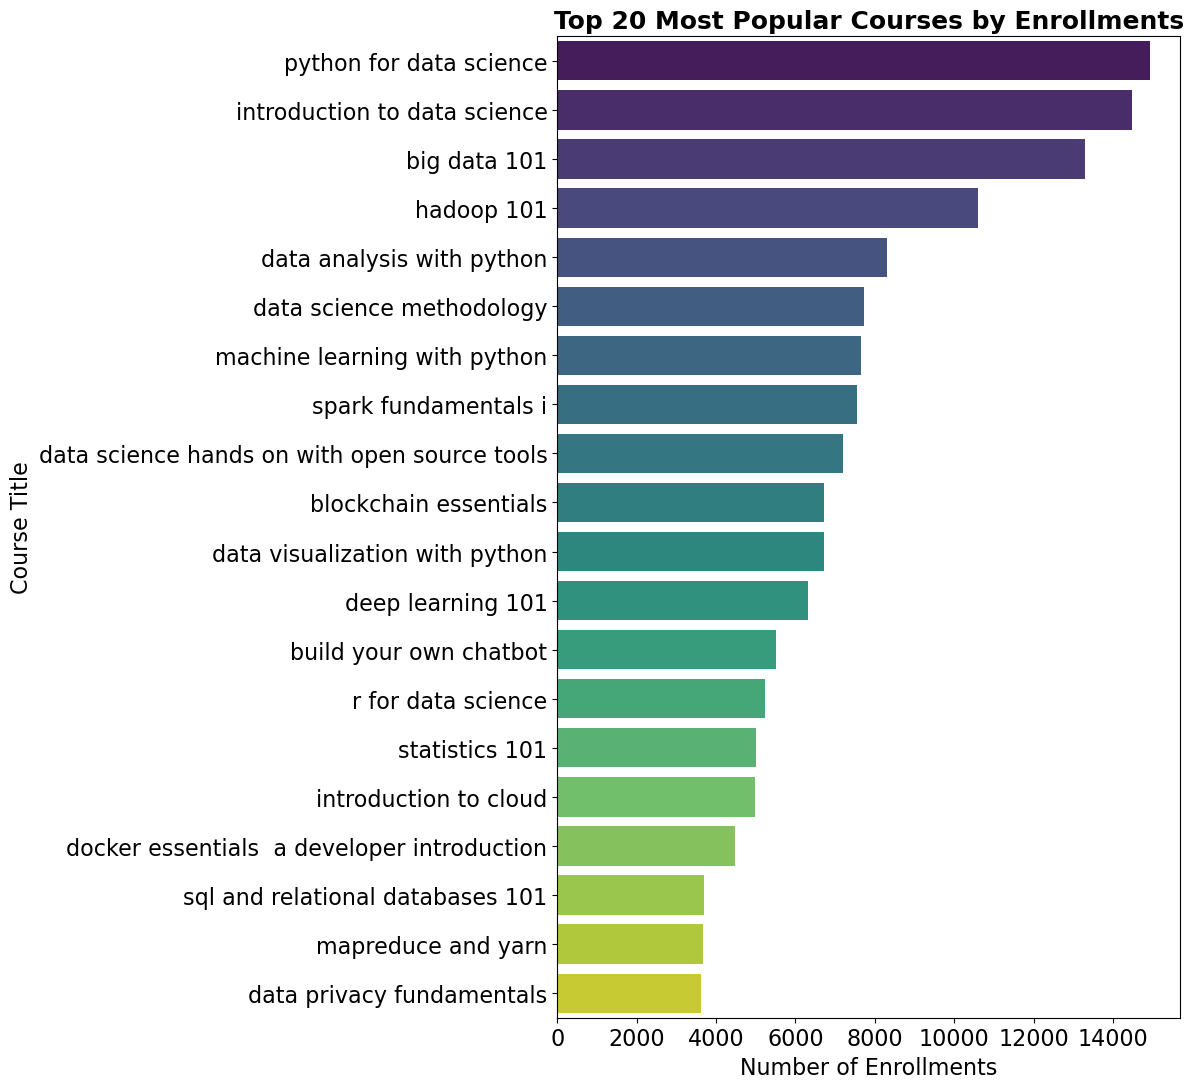

                                           TITLE  Enrolls
0                        python for data science    14936
1                   introduction to data science    14477
2                                   big data 101    13291
3                                     hadoop 101    10599
4                      data analysis with python     8303
5                       data science methodology     7719
6                   machine learning with python     7644
7                           spark fundamentals i     7551
8   data science hands on with open source tools     7199
9                          blockchain essentials     6719
10                data visualization with python     6709
11                             deep learning 101     6323
12                        build your own chatbot     5512
13                            r for data science     5237
14                                statistics 101     5015
15                         introduction to cloud     4983
16   docker es

In [66]:
# Merge top 20 courses with titles
top20_with_titles = top20_courses.merge(course_df[['COURSE_ID', 'TITLE']], 
                                        how='left', 
                                        left_on='item', 
                                        right_on='COURSE_ID')[['TITLE', 'Enrolls']]

# Create horizontal bar chart
plt.figure(figsize=(12, 11))
sns.barplot(data=top20_with_titles, 
            y='TITLE', 
            x='Enrolls', 
            palette='viridis',
            orient='h')
plt.xlabel('Number of Enrollments', fontsize=16)
plt.ylabel('Course Title', fontsize=16)
plt.title('Top 20 Most Popular Courses by Enrollments', fontsize=18, fontweight='bold')
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

# Display the data table as well
print(top20_with_titles)

<details>
    <summary>Click here for Hints</summary>
    
You can use `pd.merge()` on your dataset with `course_df[['COURSE_ID', 'TITLE']], how='left', left_on='course', right_on='COURSE_ID'` parameters. Don't forget to choose `['TITLE', 'Ratings']` columns. 


It seems that those popular courses take a huge amount of total ratings. Let's find the exact percentage.


In [67]:
# Get the total course enrollments again
total = ratings_df.shape[0]
total

233306

_TODO: Get the percentage of the top-20 course enrollments._


In [68]:
# WRITE YOUR CODE HERE
# Get top 20 courses enrollments sum
top_20_sum = top20_courses['Enrolls'].sum()

# Calculate percentage
percentage = (top_20_sum / total) * 100
print(f"Top 20 courses account for {percentage:.2f}% of total enrollments")

Top 20 courses account for 63.30% of total enrollments


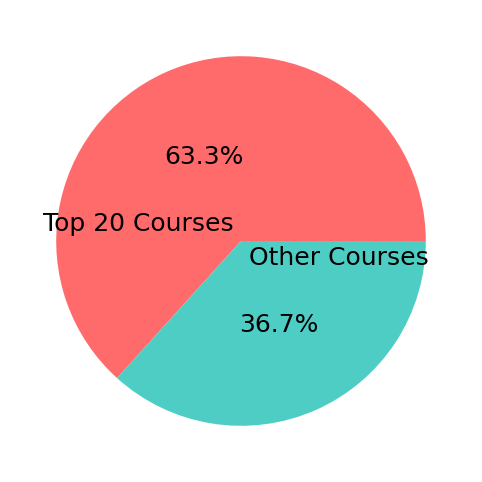

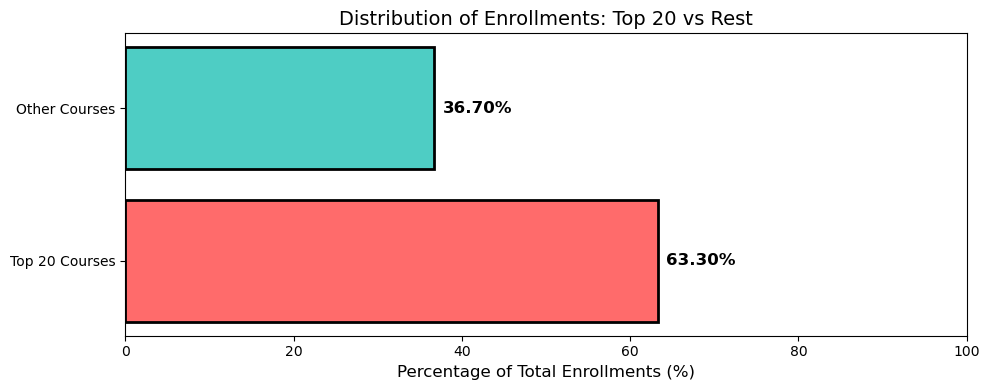

Total Enrollments: 233306
Top 20 Courses Enrollments: 147688
Other Courses Enrollments: 85618

Top 20 Courses: 63.30%
Other Courses: 36.70%


In [69]:
# Calculate the totals
other_sum = total - top_20_sum

percentage_top20 = (top_20_sum / total) * 100
percentage_other = (other_sum / total) * 100

# Option 1: Pie Chart
plt.figure(figsize=(10, 6))
plt.pie([top_20_sum, other_sum], 
        labels=['Top 20 Courses', 'Other Courses'],
        autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4'],
        startangle=0,
        textprops={'fontsize': 18},
        labeldistance=0.1,    # Distance of labels from pie (default is 1.1)
        pctdistance=0.5)
# plt.title('Percentage of Enrollments', fontsize=16)
plt.show()

# Option 2: Horizontal Bar Chart
plt.figure(figsize=(10, 4))
categories = ['Top 20 Courses', 'Other Courses']
percentages = [percentage_top20, percentage_other]
colors = ['#FF6B6B', '#4ECDC4']

plt.barh(categories, percentages, color=colors, edgecolor='black', linewidth=2)
plt.xlabel('Percentage of Total Enrollments (%)', fontsize=12)
plt.title('Distribution of Enrollments: Top 20 vs Rest', fontsize=14)
plt.xlim(0, 100)

# Add percentage labels on bars
for i, (cat, pct) in enumerate(zip(categories, percentages)):
    plt.text(pct + 1, i, f'{pct:.2f}%', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Option 3: Display Summary Statistics
print(f"Total Enrollments: {total}")
print(f"Top 20 Courses Enrollments: {top_20_sum}")
print(f"Other Courses Enrollments: {other_sum}")
print(f"\nTop 20 Courses: {percentage_top20:.2f}%")
print(f"Other Courses: {percentage_other:.2f}%")

<details>
    <summary>Click here for Hints</summary>
    
You can use sum() command on `top_courses['Ratings'].values` to get top-20 course enrollements sum. 


## **Summary**


In this lab, we performed exploratory data analysis on the course metadata and course enrollments datasets and obtained some preliminary understanding. 

These raw datasets can not be used to build recommender systems directly. Later, we will practice how to process them and extract features for machine learning tasks.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


### **Other Contributors**


[Artem Arutyunov](https://www.linkedin.com/in/artem-arutyunov/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01)


Copyright © 2021 IBM Corporation. All rights reserved.


## **Change Log**
| Date (YYYY-MM-DD) | Version | Changed By         | Change Description |
| ----------------- | ------- | ------------------ | ------------------ |
|2026-04-10 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|